# PCA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
df = pd.read_csv("wine.csv")
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [4]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [5]:
df.isnull().sum()

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

In [6]:
df = df.drop_duplicates()
df.shape
#No missing values and no duplicates in the dataset. So, we can proceed with the analysis.

(178, 14)

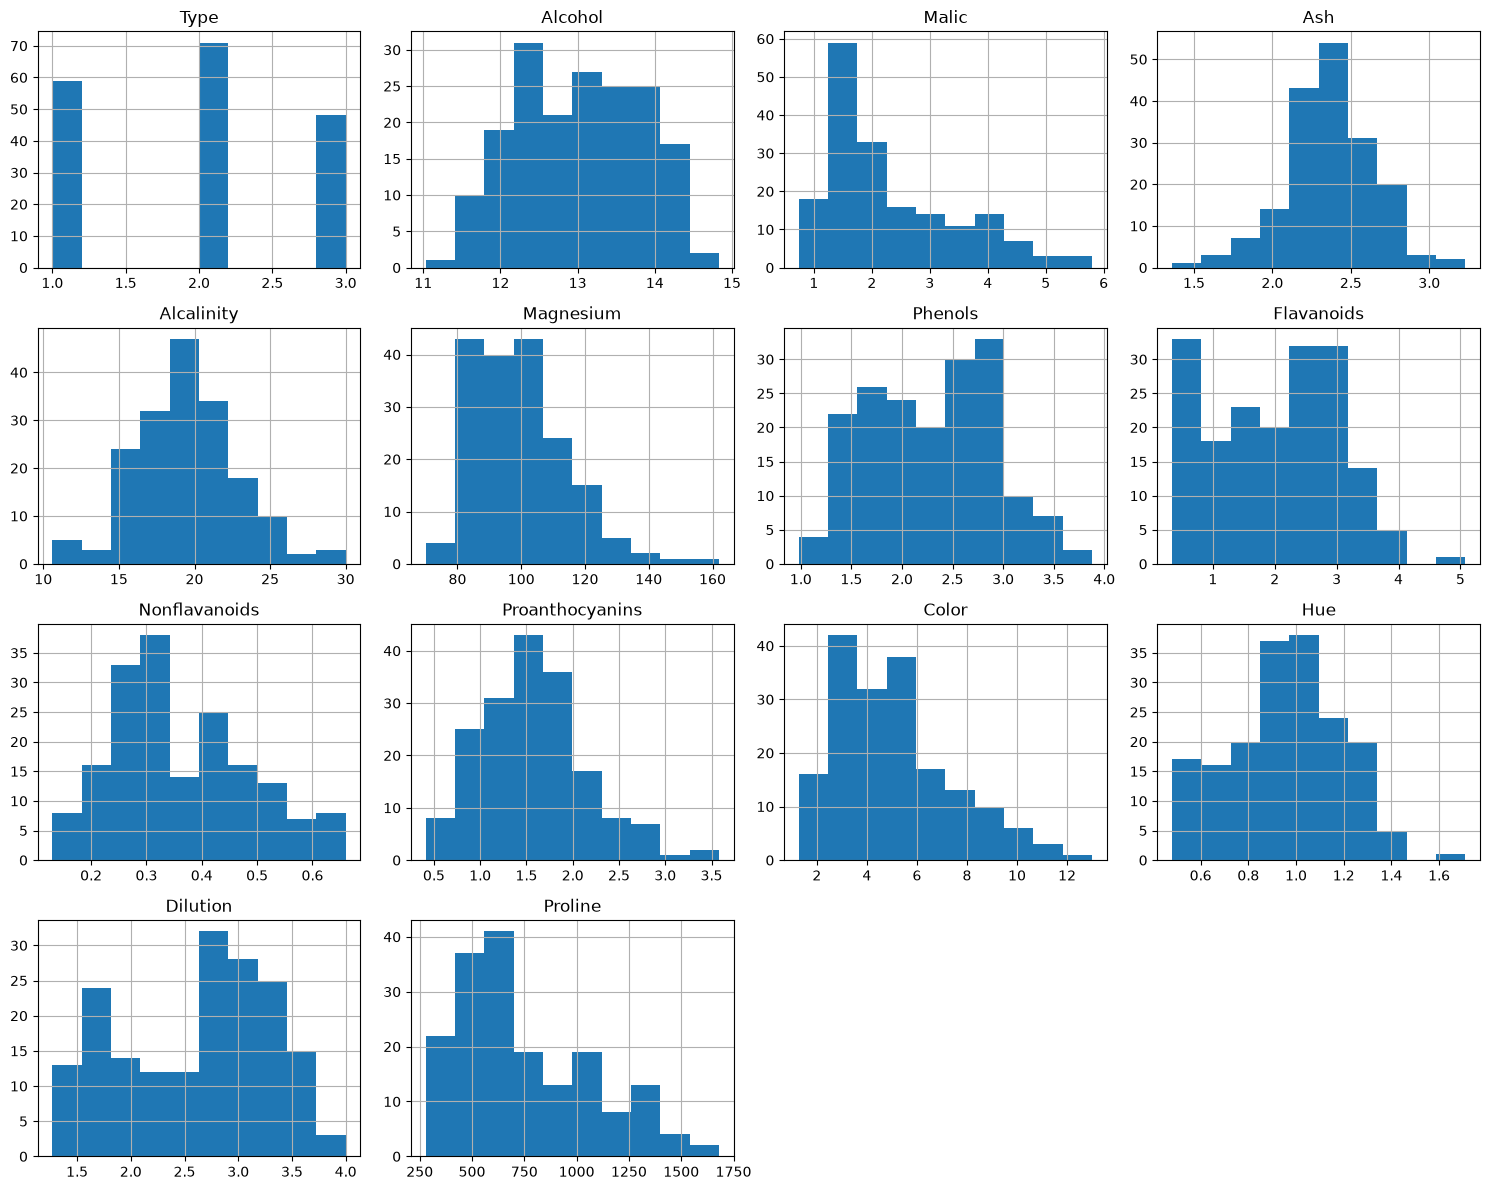

In [7]:
df.hist(figsize=(15,12))
plt.tight_layout()
plt.show()

* Type: The data contains three distinct wine categories.
* Alcohol: Most wines have alcohol content between 12 and 14.
* Malic: Most values are low, with a few higher values creating a right skew.
* Ash: The values are concentrated around 2.2 to 2.5.
* Alcalinity: Most samples have alcalinity between 16 and 21.
* Magnesium: Most wines have magnesium values between 80 and 110.
* Phenols: The values are spread mainly between 1.5 and 3.0.
* Flavanoids: Most wines have flavanoid values below 3.5 with a few high values.
* Nonflavanoids: Most observations are clustered around 0.25 to 0.40.
* Proanthocyanins: Most values lie between 1.0 and 2.0.
* Color: Most wines have color intensity between 2 and 6 with a right-skewed distribution.
* Hue: Most hue values are close to 1.0.
* Dilution: The values are mainly distributed between 2.5 and 3.5.
* Proline: Most wines have proline values between 400 and 900, with some much higher values.

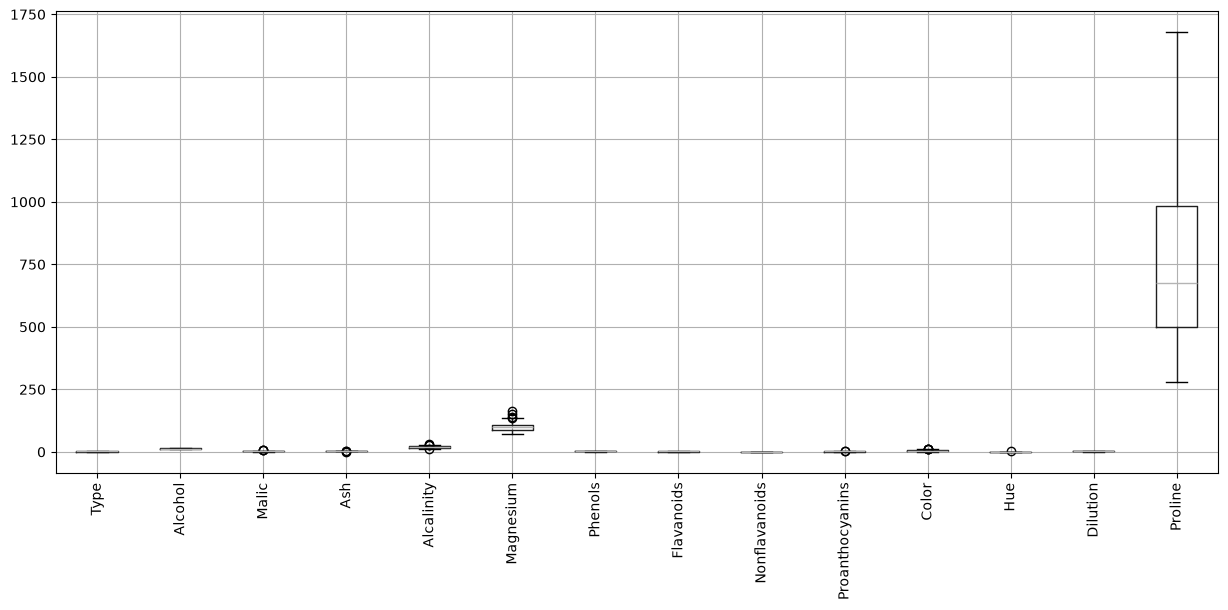

In [8]:
plt.figure(figsize=(15,6))
df.boxplot(rot=90)
plt.show()

* Most variables have a few outliers, but they are not very extreme.
* Magnesium shows a few high-value outliers compared to the rest of the data.
* Alcalinity contains some higher values that appear as outliers.
* Malic and Color have a few observations above the normal range.
* Proanthocyanins also has a small number of high-value outliers.
* Proline has the largest range of values among all the features.
* Most other variables have relatively compact distributions with fewer outliers.

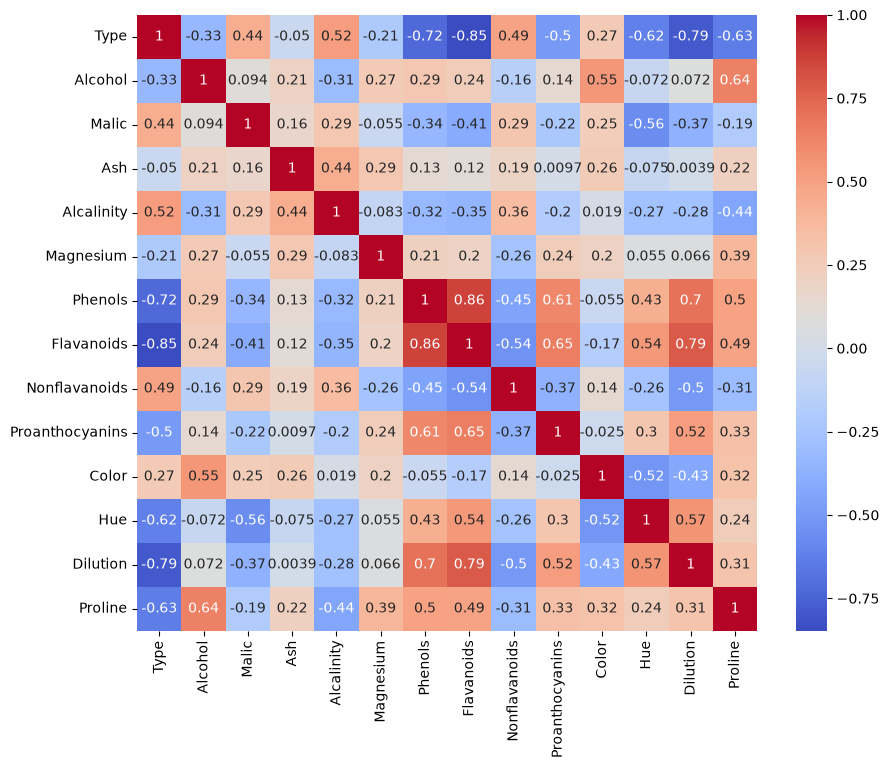

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.show()

* Phenols and Flavanoids have a very strong positive correlation.
* Flavanoids and Dilution also show a strong positive relationship.
* Alcohol has a moderate positive correlation with Proline.
* Phenols and Dilution are positively correlated, meaning they tend to increase together.
* Color has a moderate negative correlation with Hue.
* Malic has a moderate negative correlation with Hue.
* Nonflavanoids has a moderate negative correlation with Flavanoids.
* Most other feature pairs have weak or little correlation with each other.

In [10]:
scaler = StandardScaler()
scaled = scaler.fit_transform(df)

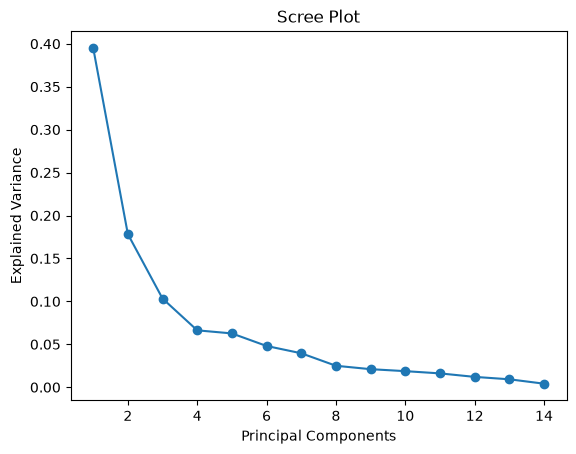

In [11]:
pca = PCA()
pca_data = pca.fit_transform(scaled)

explained = pca.explained_variance_ratio_

plt.plot(range(1,len(explained)+1),explained,marker='o')
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")
plt.title("Scree Plot")
plt.show()

The scree plot shows that the explained variance decreases sharply until the 4th principal component, after which each additional component contributes only a small amount of information.

[0.39542486 0.57378745 0.67707846 0.74335831 0.80603706 0.85409266
 0.89364973 0.91865217 0.93969088 0.95842703 0.97455906 0.98661596
 0.99587055 1.        ]


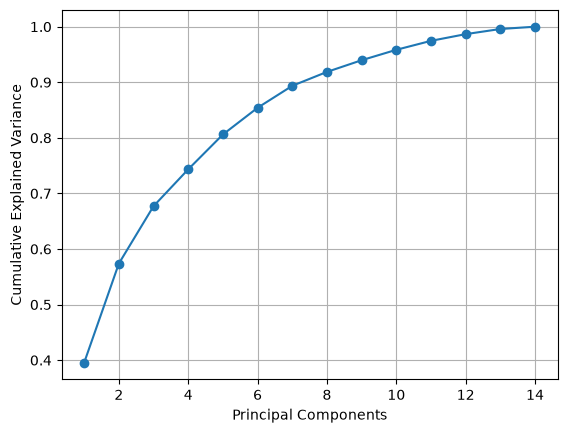

In [12]:
cum = np.cumsum(explained)
print(cum)
plt.plot(range(1,len(cum)+1),cum,marker='o')
plt.xlabel("Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

The cumulative explained variance increases rapidly for the first few principal components and then gradually decreases.

In [13]:
pca = PCA(n_components=4)
pca_data = pca.fit_transform(scaled)

pca_df = pd.DataFrame(pca_data, columns=["PC1", "PC2", "PC3", "PC4"])
pca_df.head()

,PC1,PC2,PC3,PC4
0,-3.522934,1.453098,-0.164795,-0.013273
1,-2.528858,-0.330019,-2.026707,-0.417144
2,-2.785029,1.036936,0.983238,0.664232
3,-3.922588,2.768210,-0.174968,0.565088
4,-1.407511,0.867773,2.025829,-0.440906


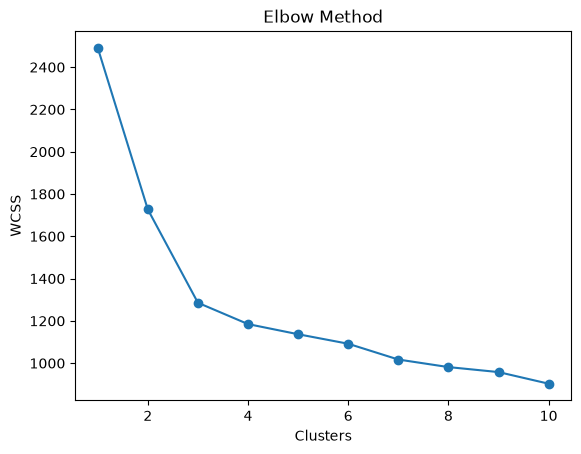

In [14]:
wcss=[]
for i in range(1,11):
    model=KMeans(n_clusters=i,random_state=42)
    model.fit(scaled)
    wcss.append(model.inertia_)

plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

The WCSS decreases sharply from 1 to 3 clusters. After 3 clusters, the curve starts flattening.

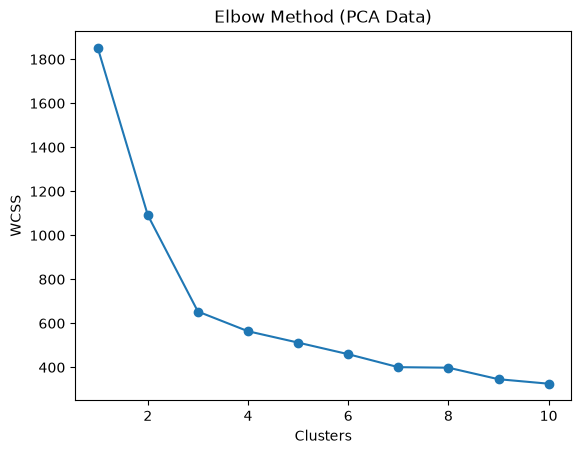

In [15]:
wcss = []

for i in range(1,11):
    model = KMeans(n_clusters=i, random_state=42)
    model.fit(pca_df)
    wcss.append(model.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method (PCA Data)")
plt.show()

The WCSS again drops sharply until 3 clusters. After 3 clusters, the decrease becomes much smaller.

### Clusters using Scaled Data

In [16]:
kmeans=KMeans(n_clusters=3,random_state=42)
labels=kmeans.fit_predict(scaled)

score=silhouette_score(scaled,labels)
print("Original Silhouette Score:",score)

Original Silhouette Score: 0.30648398324833453


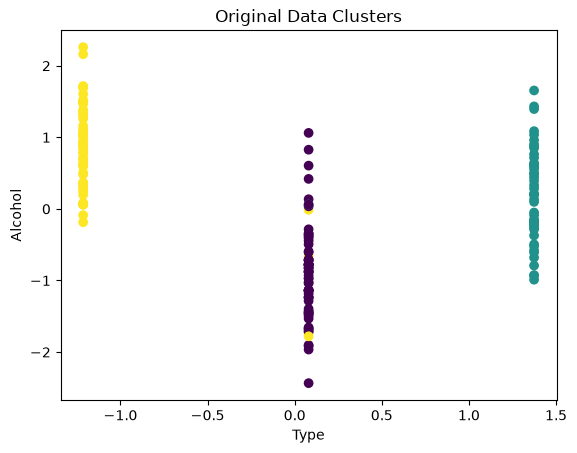

In [17]:
plt.scatter(scaled[:,0],scaled[:,1],c=labels,cmap="viridis")
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.title("Original Data Clusters")
plt.show()

### Clusters Using PCA Data

In [18]:
kmeans_pca=KMeans(n_clusters=3,random_state=42)
pca_labels=kmeans_pca.fit_predict(pca_df)

pca_score=silhouette_score(pca_df,pca_labels)
print("PCA Silhouette Score:",pca_score)

PCA Silhouette Score: 0.4367881227595952


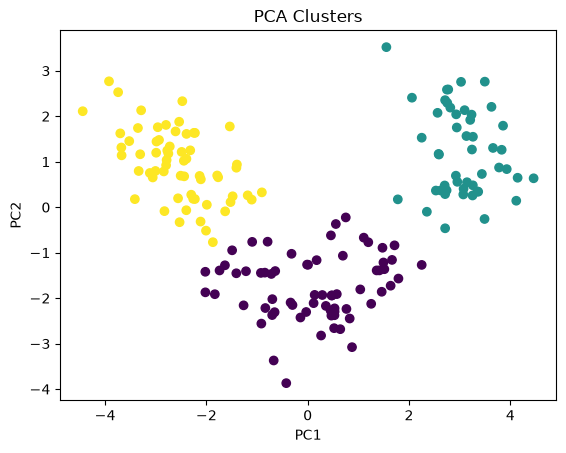

In [19]:
plt.scatter(pca_df["PC1"],pca_df["PC2"],c=pca_labels,cmap="viridis")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Clusters")
plt.show()

In [21]:
print("Original Score:",score)
print("PCA Score:",pca_score)

Original Score: 0.30648398324833453
PCA Score: 0.4367881227595952


### Conclusion



* The dataset was explored using histograms, boxplots, and a correlation heatmap, which helped understand the distribution and relationships between the features.
* PCA was applied after standardizing the data, and the scree plot indicated that the first four principal components retained most of the important information while reducing the dimensionality of the dataset.
* K-Means clustering was performed on both the original standardized data and the PCA-transformed data. The elbow method suggested that **3 clusters** were optimal in both cases.
* The clustering results were similar for the original and PCA-transformed data, showing that PCA preserved the overall structure of the dataset while reducing the number of features.
* Using PCA reduced computational complexity and simplified the data without significantly affecting clustering performance, making it a useful technique for high-dimensional datasets.
